In [1]:
library(tidyverse)
library(vroom)
library(data.table)
library(future.apply)

####### Systematic processing. ########
out_dir <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn/"
# Create outdir.
dir.create(out_dir, showWarnings = FALSE)


# First we look at all the samples that are available. 
input_dir1 <- "/mnt/dawnccle2/processed_data/satmutv2_dawn/"

# Get all full filenames in all the input dirs. 
cellline_filenames1 <- list.files(path = input_dir1, pattern = "umi_dedup_fine_grained_idx.csv$", full.names = TRUE)

# Make a df of these filenames.
cellline_paths <- data.frame(filename = c(cellline_filenames1))
cellline_paths <- cellline_paths %>% 
  mutate(basename = basename(filename)) %>%
  mutate(sample = str_extract(basename(filename), ".+(?=_umi_dedup)")) %>%
  mutate(condition = str_extract(sample, "^.+(?=_rep\\d)")) %>% 
  # Strip satmutv2_ from the condition.
  mutate(condition = str_replace(condition, "satmutv2_", "")) %>%
  mutate(rep_old = str_extract(basename(filename), "rep\\d")) %>%
  mutate(rep_new = rep_old) %>% 
  mutate(sample_new = paste0(condition, "-", rep_new))



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘vroom’


The following objects are masked from ‘package:readr’:

    as.col_spec, col_character, col_date, col_datetime, col_double,
    col_factor, col_guess, col_integer, col_logical, col_number,
    col_skip, col_time, cols, cols_condense, cols_only, date_names,
    date_names_lang, date_names_langs, default_locale, fwf_cols,
    fwf_empty, fwf_positions, fwf_widths, locale, output_column,
    problems, spec



Attaching package: ‘data.table’


The

In [2]:
cellline_paths

filename,basename,sample,condition,rep_old,rep_new,sample_new
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,satmutv2_A375_rep1_S1,A375,rep1,rep1,A375-rep1
/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep2_S2_umi_dedup_fine_grained_idx.csv,satmutv2_A375_rep2_S2_umi_dedup_fine_grained_idx.csv,satmutv2_A375_rep2_S2,A375,rep2,rep2,A375-rep2
/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep3_S3_umi_dedup_fine_grained_idx.csv,satmutv2_A375_rep3_S3_umi_dedup_fine_grained_idx.csv,satmutv2_A375_rep3_S3,A375,rep3,rep3,A375-rep3
/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_HEK_rep1_S4_umi_dedup_fine_grained_idx.csv,satmutv2_HEK_rep1_S4_umi_dedup_fine_grained_idx.csv,satmutv2_HEK_rep1_S4,HEK,rep1,rep1,HEK-rep1
/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_HEK_rep2_S5_umi_dedup_fine_grained_idx.csv,satmutv2_HEK_rep2_S5_umi_dedup_fine_grained_idx.csv,satmutv2_HEK_rep2_S5,HEK,rep2,rep2,HEK-rep2
/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_HEK_rep3_S6_umi_dedup_fine_grained_idx.csv,satmutv2_HEK_rep3_S6_umi_dedup_fine_grained_idx.csv,satmutv2_HEK_rep3_S6,HEK,rep3,rep3,HEK-rep3
/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_KELLY_rep1_S7_umi_dedup_fine_grained_idx.csv,satmutv2_KELLY_rep1_S7_umi_dedup_fine_grained_idx.csv,satmutv2_KELLY_rep1_S7,KELLY,rep1,rep1,KELLY-rep1
/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_KELLY_rep2_S8_umi_dedup_fine_grained_idx.csv,satmutv2_KELLY_rep2_S8_umi_dedup_fine_grained_idx.csv,satmutv2_KELLY_rep2_S8,KELLY,rep2,rep2,KELLY-rep2
/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_KELLY_rep3_S9_umi_dedup_fine_grained_idx.csv,satmutv2_KELLY_rep3_S9_umi_dedup_fine_grained_idx.csv,satmutv2_KELLY_rep3_S9,KELLY,rep3,rep3,KELLY-rep3


In [3]:
# Extract all metrics and append to cellline_paths
metrics_list <- lapply(1:nrow(cellline_paths), function(i) {
  filename_full <- cellline_paths$filename[i]
  sample_name <- cellline_paths$sample[i]
  filename_dir <- dirname(filename_full)
  stats_log_path <- file.path(filename_dir, paste0(sample_name, "_stats_log_fine_grained_idx.txt"))
  
  if (file.exists(stats_log_path)) {
    stats_log <- read_csv(stats_log_path, col_names = FALSE)
    colnames(stats_log) <- c("metric", "count")
    
    # Convert metrics to a named list
    metric_values <- as.list(setNames(stats_log$count, stats_log$metric))
    return(metric_values)
  } else {
    return(NULL)
  }
})

# Combine metrics with cellline_paths
metrics_df <- bind_rows(metrics_list) %>%
  mutate_all(as.character)  # Ensure consistent data type

cellline_paths <- bind_cols(cellline_paths, metrics_df)

# Filter out samples that have < 1M aligned reads.
cellline_paths_filtered <- cellline_paths %>% 
  mutate(total_aligned_reads = as.integer(total_aligned_reads)) %>% 
  filter(total_aligned_reads >= 1e6) 

# Write this metadata to file.
write_csv(cellline_paths_filtered, "/mnt/dawnccle2/melange/process_fastq_250221/10_satmutv2/cellline_sample_metadata_satmutv2.csv")


Rows: 13 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): X1
dbl (1): X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 13 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): X1
dbl (1): X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 13 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): X1
dbl (1): X2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 13 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","

In [4]:
# This is the new version of normalization based on "Version 3" math.
normalize_all_non_included_reads <- function(df, chimeric_rate) {
  df_with_stats <- df %>% 
    mutate(is_included = ifelse(mode == "INCLUDED", TRUE, FALSE)) %>% 
    group_by(index) %>% 
    mutate(
      total_count = sum(count),
      total_included_count = sum(count * is_included, na.rm = TRUE) ,
      total_not_included_count = sum(count * !is_included, na.rm = TRUE)
    ) %>% 
    ungroup()
    
  df_not_included <- df_with_stats %>% 
    filter(!is_included) %>% 
    group_by(index) %>% 
    mutate(read_frac = count / sum(count)) %>% 
    ungroup() 
  
  df_not_included <- df_not_included %>%
    mutate(count_scaled = (total_not_included_count - chimeric_rate* total_included_count)/(1+ chimeric_rate) * read_frac) %>%
    # Convert all to integer.
    mutate(count_scaled = as.integer(count_scaled)) %>% 
    # If value < 0, set to 0.
    mutate(count_scaled = ifelse(count_scaled < 0, 0, count_scaled)) %>% 
    select(-is_included, -total_count, -total_included_count, -total_not_included_count, -read_frac)
  
  return(df_not_included)
}



# Parallel version of merge_offsets_to_ref.
merge_offsets_to_ref_parallel <- function(df, workers = 64) {
  plan(multisession, workers = workers)

  # Preprocess and split
  df_sep <- df %>%
    separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":", remove = FALSE) %>%
    mutate(index_full = paste0(index, "_", offset_initial, "_", design)) %>% 
    mutate(across(c(upstream_offset, downstream_offset, const_offset), as.integer)) %>%
    as.data.table()

  cat("done separating\n")

  # Split by index (parallelizable units)
  df_list <- split(df_sep, by = "index_full")
  # Greedy merge function (same as before, per index)
  greedy_merge_index <- function(df_idx) {
    setorder(df_idx, -count)
    merged <- data.table()

    while (nrow(df_idx) > 0) {
      anchor <- df_idx[1]
      u0 <- anchor$upstream_offset
      d0 <- anchor$downstream_offset
      c0 <- anchor$const_offset

      neighbors <- df_idx[
        upstream_offset %between% c(u0 - 1, u0 + 1) &
        downstream_offset %between% c(d0 - 1, d0 + 1)
      ]

      anchor$count <- sum(neighbors$count)
      merged <- rbind(merged, anchor, use.names = TRUE)
      df_idx <- fsetdiff(df_idx, neighbors)
    }

    return(merged)
  }

  # Run in parallel across indices
  results <- future_lapply(df_list, greedy_merge_index)

  # Combine and clean
  out <- rbindlist(results)
  out[, c("upstream_offset", "downstream_offset", "const_offset", "index_full") := NULL]
  return(out[])
}

# Get all unique sample_new names.
unique_samples <- cellline_paths_filtered %>% group_by(sample_new) %>% summarise(n=n()) %>% ungroup() 
unique_sample_names <- unique(cellline_paths_filtered$sample_new)

# merge_offsets_to_ref_parallel(tmp_included_sequences_only)


In [5]:
unique_sample_names


[1] "A375-rep1"  "A375-rep2"  "A375-rep3"  "HEK-rep1"   "HEK-rep2"  
 [6] "HEK-rep3"   "KELLY-rep1" "KELLY-rep2" "KELLY-rep3" "T47D-rep1" 
[11] "T47D-rep2"  "T47D-rep3"

In [6]:
# Merge offsets. For each index, take the biggest offset, and then assign the +/-1 offset counts to the counts of the biggest offset.
# Iterate until there are no more offsets to merge.
merge_offsets_to_ref <- function(df){
  print("Merging offsets to ref")
  print(head(df))
  df_sep <- df %>% 
  ungroup() %>% 
  separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":", remove = FALSE) %>% 
  mutate(upstream_offset = as.integer(upstream_offset), downstream_offset = as.integer(downstream_offset), const_offset = as.integer(const_offset)) %>% 
  mutate(index_full = paste0(index, "_", offset_initial, "_", design))
  cat("done separating\n")
  unique_indices <- unique(df_sep$index_full)
  print(head(unique_indices))
  new_df <- data.frame()
  for (idx in unique_indices){
    df_tmp_idx <- df_sep %>% 
      filter(index_full == idx) %>% 
      arrange(desc(count))
    # cat("################## before merging dataframe for index:", idx, "\n")
    # print(df_tmp_idx, n = nrow(df_tmp_idx), width = Inf)
    new_df_tmp_idx <- data.frame()
    while (nrow(df_tmp_idx) > 0){
      max_offset_row <- df_tmp_idx %>% slice(1)
      max_offset_val_upstream <- max_offset_row$upstream_offset
      max_offset_val_downstream <- max_offset_row$downstream_offset
      # Get all possible offses for upstream_offset, downstream_offset. +/- 1.
      possible_offset_rows <- df_tmp_idx %>% 
      filter((upstream_offset == max_offset_val_upstream + 1 & downstream_offset == max_offset_val_downstream) |
             (upstream_offset == max_offset_val_upstream - 1 & downstream_offset == max_offset_val_downstream) |
             (upstream_offset == max_offset_val_upstream & downstream_offset == max_offset_val_downstream + 1) |
             (upstream_offset == max_offset_val_upstream & downstream_offset == max_offset_val_downstream - 1) |
             (upstream_offset == max_offset_val_upstream & downstream_offset == max_offset_val_downstream) |
             (upstream_offset == max_offset_val_upstream + 1 & downstream_offset == max_offset_val_downstream + 1) |
             (upstream_offset == max_offset_val_upstream + 1 & downstream_offset == max_offset_val_downstream - 1) |
             (upstream_offset == max_offset_val_upstream - 1 & downstream_offset == max_offset_val_downstream + 1) |
             (upstream_offset == max_offset_val_upstream - 1 & downstream_offset == max_offset_val_downstream - 1))
      # Merge the counts for these possible_offset_rows. And assign the count to the max_offset_row.
      merged_counts <- possible_offset_rows %>% pull(count) %>% sum()
      max_offset_row$count <- merged_counts
      # Remove the possible_offset_rows from df_tmp_idx. Need to be the exact pairs that are in possible_offset_rows.
      # Filter out the exact pairs that are in possible_offset_rows
      df_tmp_idx <- anti_join(df_tmp_idx, possible_offset_rows, 
                             by = c("upstream_offset", "downstream_offset", "const_offset"))
      # Add the max_offset_row to new_df_tmp_idx.
      new_df_tmp_idx <- bind_rows(new_df_tmp_idx, max_offset_row)
    }
    # cat("Final merged dataframe for index:", idx, "\n")
    #print(new_df_tmp_idx)
    new_df <- bind_rows(new_df, new_df_tmp_idx)
  }
  # Remove the upstream_offset, downstream_offset, const_offset columns.
  new_df <- new_df %>% select(-upstream_offset, -downstream_offset, -const_offset, -index_full)
  return(new_df)
}

for (sample_tmp in unique_sample_names){
  # Get all the filepaths with that sample name.
  sample_filepaths <- cellline_paths_filtered %>% filter(sample_new == sample_tmp) %>% pull(filename)
  tmp_out <- data.frame()
  for (filepath in sample_filepaths) {
    base::print(paste("Processing", filepath))
    # Get the parent folder name from the filepath. (not full path)
    parent_folder <- basename(dirname(filepath))
    # Get basename and strip _umi_dedup_fine_grained_idx.csv
    filename_basename <- basename(filepath) %>% str_extract(".+(?=_umi_dedup_fine_grained_idx.csv)")
    
    # Read in the tsv file.
    tmp <- vroom(filepath, id = "filename", delim = ",") %>% 
    filter(grepl("R1design", index))
    
    # Get chimeric rate from the metadata table. 
    chimeric_rate <- cellline_paths_filtered %>% 
      filter(filename == filepath) %>% 
      pull(perc_chimera_reads)
    base::print(paste("chimeric_rate:", chimeric_rate))
    
    # Separate the "index" column into id, mode, offset, insert_size based on __ separator.
    tmp_to_ref <- tmp %>% 
      separate(index, into = c("index", "offset_initial", "design", "mode", "offset" ,"insert_size"), sep = "__", remove = FALSE) %>% 
      select(-insert_size)
    
    # Split into included (need offset merging), and everything else (need adjustment).
    # We just directly adjust the counts for non-included as count_scaled = count * (1 - chimeric_rate).
    tmp_included_sequences_only <- tmp_to_ref %>% filter(mode == "INCLUDED") 
    tmp_included_merged_offsets <- merge_offsets_to_ref(tmp_included_sequences_only) %>% mutate(count_scaled = count)
    # Normalize the non-included reads.  
    tmp_everything_else <- tmp_to_ref %>% filter(mode != "INCLUDED") %>% mutate(count_scaled = count)
    
    tmp_final <- bind_rows(tmp_included_merged_offsets, tmp_everything_else)

    # Write tmp_final to file.
    fwrite(tmp_final, file.path(out_dir, paste0(parent_folder, "-individual-", filename_basename, "_umi_dedup_normalized_tmp.tsv")))

    tmp_out <- bind_rows(tmp_out, tmp_final) %>%
      group_by(filename, index, offset_initial, design, mode, offset) %>% 
      summarise(count = sum(count), count_scaled = sum(count_scaled))
  }
  
  # Write to outdir. 
  base::print(paste("Writing to", file.path(out_dir, paste0(sample_tmp, "_umi_dedup_normalized.tsv"))))
  fwrite(tmp_out, file.path(out_dir, paste0(sample_tmp, "_umi_dedup_normalized.tsv")))
}

[1] "Processing /mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv"


Rows: 101022 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): index
dbl (1): count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "chimeric_rate: 0.133792672941017"
[1] "Merging offsets to ref"
# A tibble: 6 × 7
  filename                        index offset_initial design mode  offset count
  <chr>                           <chr> <chr>          <chr>  <chr> <chr>  <dbl>
1 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          R1des… INCL… 0:-14…     1
2 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          R1des… INCL… 0:0:0     61
3 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          R1des… INCL… 0:0:0      1
4 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          vae_0… INCL… 10:-2…     3
5 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          vae_0… INCL… 10:1:0     2
6 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          vae_0… INCL… 10:2:0     3
done separating
[1] "ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350_0:0:0_R1design0"             
[2] "ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350_0:0:0_vae_0_to_10_R1design10"
[3] "ENSG0

`summarise()` has grouped output by 'filename', 'index', 'offset_initial',
'design', 'mode'. You can override using the `.groups` argument.


[1] "Writing to /mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn//A375-rep1_umi_dedup_normalized.tsv"
[1] "Processing /mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep2_S2_umi_dedup_fine_grained_idx.csv"


...

[1] "Writing to /mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn//T47D-rep2_umi_dedup_normalized.tsv"
[1] "Processing /mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_T47D_rep3_S12_umi_dedup_fine_grained_idx.csv"


Rows: 94443 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): index
dbl (1): count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "chimeric_rate: 0.134078544187571"
[1] "Merging offsets to ref"
# A tibble: 6 × 7
  filename                        index offset_initial design mode  offset count
  <chr>                           <chr> <chr>          <chr>  <chr> <chr>  <dbl>
1 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          R1des… INCL… 0:0:0     50
2 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          vae_0… INCL… 10:1:0     1
3 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          vae_0… INCL… 10:2:0     1
4 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          vae_0… INCL… 10:2:0   821
5 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          vae_0… INCL… 10:2:0     1
6 /mnt/dawnccle2/processed_data/… ENSG… 0:0:0          vae_0… INCL… 24:2:0     1
done separating
[1] "ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350_0:0:0_R1design0"             
[2] "ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350_0:0:0_vae_0_to_10_R1design10"
[3] "ENSG0

`summarise()` has grouped output by 'filename', 'index', 'offset_initial',
'design', 'mode'. You can override using the `.groups` argument.


[1] "Writing to /mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn//T47D-rep3_umi_dedup_normalized.tsv"


# Maile single base saturation mutagenesis files

In [7]:
# Also do for Maile files
merge_offsets_to_ref <- function(df){
  print("Merging offsets to ref")
  print(head(df))
  df_sep <- df %>% 
  ungroup() %>% 
  separate(offset, into = c("upstream_offset", "downstream_offset", "const_offset"), sep = ":", remove = FALSE) %>% 
  mutate(upstream_offset = as.integer(upstream_offset), downstream_offset = as.integer(downstream_offset), const_offset = as.integer(const_offset)) %>% 
  mutate(index_full = paste0(index, "_", offset_initial, "_", location, "_", base))
  cat("done separating\n")
  unique_indices <- unique(df_sep$index_full)
  print(head(unique_indices))
  new_df <- data.frame()
  for (idx in unique_indices){
    df_tmp_idx <- df_sep %>% 
      filter(index_full == idx) %>% 
      arrange(desc(count))
    # cat("################## before merging dataframe for index:", idx, "\n")
    # print(df_tmp_idx, n = nrow(df_tmp_idx), width = Inf)
    new_df_tmp_idx <- data.frame()
    while (nrow(df_tmp_idx) > 0){
      max_offset_row <- df_tmp_idx %>% slice(1)
      max_offset_val_upstream <- max_offset_row$upstream_offset
      max_offset_val_downstream <- max_offset_row$downstream_offset
      # Get all possible offses for upstream_offset, downstream_offset. +/- 1.
      possible_offset_rows <- df_tmp_idx %>% 
      filter((upstream_offset == max_offset_val_upstream + 1 & downstream_offset == max_offset_val_downstream) |
             (upstream_offset == max_offset_val_upstream - 1 & downstream_offset == max_offset_val_downstream) |
             (upstream_offset == max_offset_val_upstream & downstream_offset == max_offset_val_downstream + 1) |
             (upstream_offset == max_offset_val_upstream & downstream_offset == max_offset_val_downstream - 1) |
             (upstream_offset == max_offset_val_upstream & downstream_offset == max_offset_val_downstream) |
             (upstream_offset == max_offset_val_upstream + 1 & downstream_offset == max_offset_val_downstream + 1) |
             (upstream_offset == max_offset_val_upstream + 1 & downstream_offset == max_offset_val_downstream - 1) |
             (upstream_offset == max_offset_val_upstream - 1 & downstream_offset == max_offset_val_downstream + 1) |
             (upstream_offset == max_offset_val_upstream - 1 & downstream_offset == max_offset_val_downstream - 1))
      # Merge the counts for these possible_offset_rows. And assign the count to the max_offset_row.
      merged_counts <- possible_offset_rows %>% pull(count) %>% sum()
      max_offset_row$count <- merged_counts
      # Remove the possible_offset_rows from df_tmp_idx. Need to be the exact pairs that are in possible_offset_rows.
      # Filter out the exact pairs that are in possible_offset_rows
      df_tmp_idx <- anti_join(df_tmp_idx, possible_offset_rows, 
                             by = c("upstream_offset", "downstream_offset", "const_offset"))
      # Add the max_offset_row to new_df_tmp_idx.
      new_df_tmp_idx <- bind_rows(new_df_tmp_idx, max_offset_row)
    }
    # cat("Final merged dataframe for index:", idx, "\n")
    #print(new_df_tmp_idx)
    new_df <- bind_rows(new_df, new_df_tmp_idx)
  }
  # Remove the upstream_offset, downstream_offset, const_offset columns.
  new_df <- new_df %>% select(-upstream_offset, -downstream_offset, -const_offset, -index_full)
  return(new_df)
}

for (sample_tmp in unique_sample_names){
  # Get all the filepaths with that sample name.
  sample_filepaths <- cellline_paths_filtered %>% filter(sample_new == sample_tmp) %>% pull(filename)
  tmp_out <- data.frame()
  for (filepath in sample_filepaths) {
    base::print(paste("Processing", filepath))
    # Get the parent folder name from the filepath. (not full path)
    parent_folder <- basename(dirname(filepath))
    # Get basename and strip _umi_dedup_fine_grained_idx.csv
    filename_basename <- basename(filepath) %>% str_extract(".+(?=_umi_dedup_fine_grained_idx.csv)")
    
    # Read in the tsv file.
    tmp <- vroom(filepath, id = "filename", delim = ",") %>% 
    filter(!grepl("R1design", index)) %>% 
    filter(!grepl("R1singlemut", index)) %>% 
    filter(!grepl("R1Kelly", index)) 
    
    # Get chimeric rate from the metadata table. 
    chimeric_rate <- cellline_paths_filtered %>% 
      filter(filename == filepath) %>% 
      pull(perc_chimera_reads)
    base::print(paste("chimeric_rate:", chimeric_rate))
    
    # Separate the "index" column into id, mode, offset, insert_size based on __ separator.
    tmp_to_ref <- tmp %>% 
      separate(index, into = c("index", "offset_initial_tmp", "mode", "offset" ,"insert_size"), sep = "__", remove = FALSE) %>% 
      separate(offset_initial_tmp, into = c("offset_initial", "location", "base"), sep = "_", remove = FALSE) %>% 
      select(-insert_size)
    
    # Split into included (need offset merging), and everything else (need adjustment).
    # We just directly adjust the counts for non-included as count_scaled = count * (1 - chimeric_rate).
    tmp_included_sequences_only <- tmp_to_ref %>% filter(mode == "INCLUDED") 
    tmp_included_merged_offsets <- merge_offsets_to_ref(tmp_included_sequences_only) %>% mutate(count_scaled = count)
    # Normalize the non-included reads.  
    tmp_everything_else <- tmp_to_ref %>% filter(mode != "INCLUDED") %>% mutate(count_scaled = count)
    
    tmp_final <- bind_rows(tmp_included_merged_offsets, tmp_everything_else)

    tmp_out <- bind_rows(tmp_out, tmp_final) %>% 
                  group_by(filename, index, offset_initial_tmp, offset_initial, location, base, mode, offset) %>% 
                  summarise(count = sum(count), count_scaled = sum(count_scaled)) %>% 
                  arrange(index, offset_initial_tmp, offset)
  }
  
  # Write to outdir. 
  base::print(paste("Writing to", file.path(out_dir, paste0(sample_tmp, "_umi_dedup_normalized_satmutv2.tsv"))))
  fwrite(tmp_out, file.path(out_dir, paste0(sample_tmp, "_umi_dedup_normalized_satmutv2.tsv")))
}

[1] "Processing /mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv"


Rows: 101022 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): index
dbl (1): count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "chimeric_rate: 0.133792672941017"


Warning message:
“Expected 3 pieces. Missing pieces filled with `NA` in 137 rows [1723, 1724,
1725, 1726, 1727, 1728, 1729, 1730, 1731, 1732, 5182, 5183, 5184, 5185, 5186,
5187, 5188, 5189, 5190, 8981, ...].”


[1] "Merging offsets to ref"
# A tibble: 6 × 9
  filename   index offset_initial_tmp offset_initial location base  mode  offset
  <chr>      <chr> <chr>              <chr>          <chr>    <chr> <chr> <chr> 
1 /mnt/dawn… ENSG… 0:0:0_downstream_… 0:0:0          downstr… 10A   INCL… 0:0:0 
2 /mnt/dawn… ENSG… 0:0:0_downstream_… 0:0:0          downstr… 10G   INCL… -1:0:0
3 /mnt/dawn… ENSG… 0:0:0_downstream_… 0:0:0          downstr… 10G   INCL… 0:0:0 
4 /mnt/dawn… ENSG… 0:0:0_downstream_… 0:0:0          downstr… 10G   INCL… 0:0:0 
5 /mnt/dawn… ENSG… 0:0:0_downstream_… 0:0:0          downstr… 10G   INCL… 0:0:0 
6 /mnt/dawn… ENSG… 0:0:0_downstream_… 0:0:0          downstr… 10G   INCL… 323:3…
# ℹ 1 more variable: count <dbl>
done separating
[1] "ENSG00000075711.21;DLG1;chr3-197075836-197075870-197066703-197066754-197076585-197076682_0:0:0_downstream_10A"
[2] "ENSG00000075711.21;DLG1;chr3-197075836-197075870-197066703-197066754-197076585-197076682_0:0:0_downstream_10G"
[3] "ENSG00000075711.21;

...

[1] "chimeric_rate: 0.134078544187571"


Warning message:
“Expected 3 pieces. Missing pieces filled with `NA` in 132 rows [1601, 1602,
1603, 1604, 1605, 1606, 1607, 1608, 1609, 1610, 1611, 1612, 4993, 4994, 4995,
4996, 4997, 4998, 4999, 5000, ...].”


[1] "Merging offsets to ref"
# A tibble: 6 × 9
  filename   index offset_initial_tmp offset_initial location base  mode  offset
  <chr>      <chr> <chr>              <chr>          <chr>    <chr> <chr> <chr> 
1 /mnt/dawn… ENSG… 0:0:0_downstream_… 0:0:0          downstr… 10A   INCL… -1:0:0
2 /mnt/dawn… ENSG… 0:0:0_downstream_… 0:0:0          downstr… 10A   INCL… 0:0:0 
3 /mnt/dawn… ENSG… 0:0:0_downstream_… 0:0:0          downstr… 10A   INCL… 1:0:0 
4 /mnt/dawn… ENSG… 0:0:0_downstream_… 0:0:0          downstr… 10A   INCL… 323:3…
5 /mnt/dawn… ENSG… 0:0:0_downstream_… 0:0:0          downstr… 10G   INCL… 0:0:0 
6 /mnt/dawn… ENSG… 0:0:0_downstream_… 0:0:0          downstr… 10T   INCL… -1:0:0
# ℹ 1 more variable: count <dbl>
done separating
[1] "ENSG00000075711.21;DLG1;chr3-197075836-197075870-197066703-197066754-197076585-197076682_0:0:0_downstream_10A"
[2] "ENSG00000075711.21;DLG1;chr3-197075836-197075870-197066703-197066754-197076585-197076682_0:0:0_downstream_10G"
[3] "ENSG00000075711.21;

`summarise()` has grouped output by 'filename', 'index', 'offset_initial_tmp',
'offset_initial', 'location', 'base', 'mode'. You can override using the
`.groups` argument.


[1] "Writing to /mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn//T47D-rep3_umi_dedup_normalized_satmutv2.tsv"


# Merge the samples into 1 file

In [8]:
# Merge samples into one file. 
library(tidyverse)
library(vroom)
library(data.table)

out_dir <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn/"
dir.create(out_dir, showWarnings = FALSE)

process_samples <- function(input_dir, sample_type, out_dir) {
  dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
  
  input_filenames <- list.files(path = input_dir, pattern = "umi_dedup_normalized.tsv$", full.names = TRUE)
  
  # Precompute sample and condition for each file
  file_metadata <- tibble(
    filename = input_filenames,
    sample = basename(input_filenames) %>% str_extract(".+(?=_umi_dedup_normalized.tsv)"),
    condition = str_extract(basename(input_filenames), "^.+(?=-rep\\d)")
  )
  
  # Read data and attach metadata
  all_files_df <- map_dfr(seq_along(file_metadata$filename), function(i) {
    df <- vroom(file_metadata$filename[i], delim = ",")
    df$sample <- file_metadata$sample[i]
    df$condition <- file_metadata$condition[i]
    df
  })
  
  fwrite(all_files_df, file.path(out_dir, paste0(sample_type, "_all_samples_raw_counts.csv")))
}

# Define input and output directories
input_output_mapping <- list(
  list(input_dir = "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn/", 
       sample_type = "satmutv2_dawn", 
       out_dir = "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn/")
)

# Process each sample type
walk(input_output_mapping, ~process_samples(.x$input_dir, .x$sample_type, .x$out_dir))

Rows: 24767 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): filename, index, offset_initial, design, mode, offset
dbl (2): count, count_scaled

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 25335 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): filename, index, offset_initial, design, mode, offset
dbl (2): count, count_scaled

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 25468 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): filename, index, offset_initial, design, mode, offset
dbl (2): count, count_scaled

ℹ Use `spec()` to retrieve the full column specification

In [9]:
# Merge samples into one file. 
library(tidyverse)
library(vroom)
library(data.table)

out_dir <- "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn/"
dir.create(out_dir, showWarnings = FALSE)

process_samples <- function(input_dir, sample_type, out_dir) {
  dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
  
  input_filenames <- list.files(path = input_dir, pattern = "umi_dedup_normalized_satmutv2.tsv$", full.names = TRUE)
  
  # Precompute sample and condition for each file
  file_metadata <- tibble(
    filename = input_filenames,
    sample = basename(input_filenames) %>% str_extract(".+(?=_umi_dedup_normalized_satmutv2.tsv)"),
    condition = str_extract(basename(input_filenames), "^.+(?=-rep\\d)")
  )
  
  # Read data and attach metadata
  all_files_df <- map_dfr(seq_along(file_metadata$filename), function(i) {
    df <- vroom(file_metadata$filename[i], delim = ",")
    df$sample <- file_metadata$sample[i]
    df$condition <- file_metadata$condition[i]
    df
  })
  
  print(paste("Writing to", file.path(out_dir, paste0(sample_type, "_all_samples_raw_counts_satmutv2.csv"))))
  fwrite(all_files_df, file.path(out_dir, paste0(sample_type, "_all_samples_raw_counts_satmutv2.csv")))
}

# Define input and output directories
input_output_mapping <- list(
  list(input_dir = "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn/", 
       sample_type = "satmutv2_dawn", 
       out_dir = "/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn/")
)

# Process each sample type
walk(input_output_mapping, ~process_samples(.x$input_dir, .x$sample_type, .x$out_dir))

Rows: 41420 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (8): filename, index, offset_initial_tmp, offset_initial, location, base...
dbl (2): count, count_scaled

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 42440 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (8): filename, index, offset_initial_tmp, offset_initial, location, base...
dbl (2): count, count_scaled

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 42035 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (8): filename, index, offset_initial_tmp, offset_initial, location, base...
dbl (2): count, count_scaled

ℹ 

[1] "Writing to /mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn//satmutv2_dawn_all_samples_raw_counts_satmutv2.csv"


# Now analyze the data

In [10]:
raw_df <- read.csv("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn/satmutv2_dawn_all_samples_raw_counts.csv")
head(raw_df)

,filename,index,offset_initial,design,mode,offset,count,count_scaled,sample,condition
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
1,/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350,0:0:0,R1design0,INCLUDED,0:-14:0,1,1,A375-rep1,A375
2,/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350,0:0:0,R1design0,INCLUDED,0:0:0,62,62,A375-rep1,A375
3,/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350,0:0:0,R1design0,SKIPPED,0,99,99,A375-rep1,A375
4,/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350,0:0:0,R1design0,UNSPLICED,0,1,1,A375-rep1,A375
5,/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350,0:0:0,R1design0,UNSPLICED,113,1,1,A375-rep1,A375
6,/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350,0:0:0,vae_0_to_10_R1design10,INCLUDED,10:-25:0,3,3,A375-rep1,A375


In [11]:
raw_df_clean <- raw_df %>%
    mutate(index_offset = paste0(index, "__", offset_initial)) %>% 
    select(-filename, - index, - offset_initial) %>%
    filter(mode %in% c("INCLUDED", "SKIPPED")) %>% 
    group_by(sample, condition, index_offset, mode, offset, design) %>%
    summarise(count = sum(count)) %>% 
    arrange(sample, condition, index_offset, design)
head(raw_df_clean)

`summarise()` has grouped output by 'sample', 'condition', 'index_offset',
'mode', 'offset'. You can override using the `.groups` argument.


sample,condition,index_offset,mode,offset,design,count
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,INCLUDED,0:-14:0,R1design0,1
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,INCLUDED,0:0:0,R1design0,62
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,SKIPPED,0,R1design0,99
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,INCLUDED,10:-25:0,vae_0_to_10_R1design10,3
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,INCLUDED,10:2:0,vae_0_to_10_R1design10,1374
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,SKIPPED,0,vae_0_to_10_R1design10,53


In [12]:
raw_df_to_psi <- raw_df_clean %>% 
    group_by(sample, condition, index_offset, mode, design) %>%
    summarise(count = sum(count)) %>% 
    ungroup() %>% 
    pivot_wider(names_from = mode, values_from = count, values_fill = 0) %>%
    mutate(total_counts = INCLUDED + SKIPPED) %>%
    filter(total_counts >= 30) %>%
    mutate(PSI = log2((INCLUDED+1) / (SKIPPED+1)))

head(raw_df_to_psi)

`summarise()` has grouped output by 'sample', 'condition', 'index_offset',
'mode'. You can override using the `.groups` argument.


sample,condition,index_offset,design,INCLUDED,SKIPPED,total_counts,PSI
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,R1design0,63,99,162,-0.6438562
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design10,1377,53,1430,4.6734727
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design11,927,38,965,4.5725788
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design12,307,22,329,3.7432246
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design13,248,9,257,4.6380738
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design14,808,20,828,5.2676785


Warning message:
“Removed 633 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 633 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 533 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 533 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2956 rows containing missing values or values outside the scale range
(`geom_point()`).”


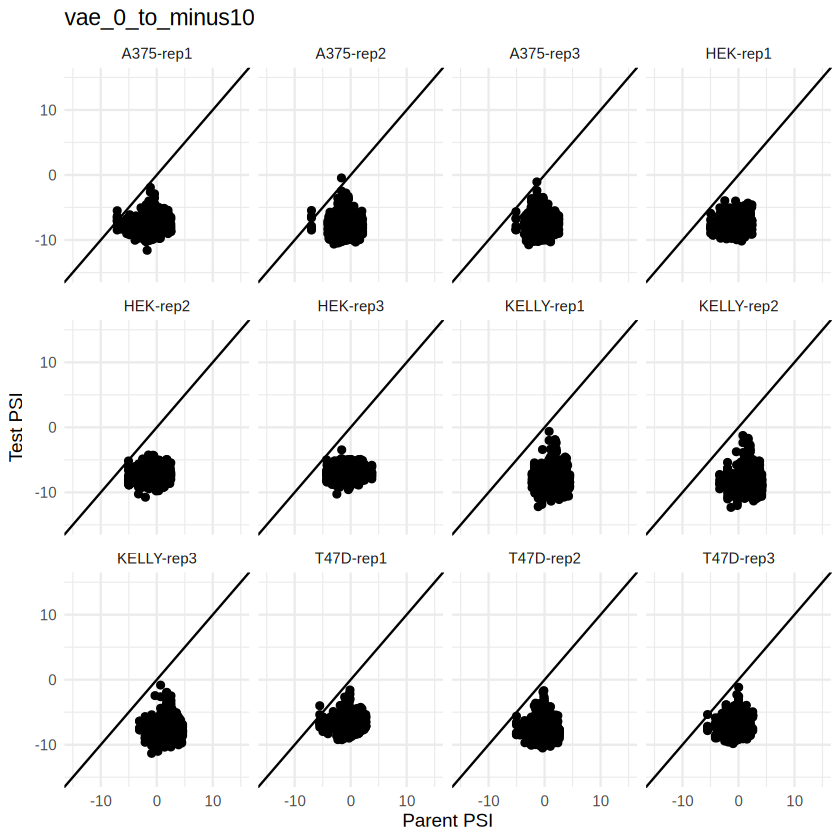

Warning message:
“Removed 2956 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 4066 rows containing missing values or values outside the scale range
(`geom_point()`).”


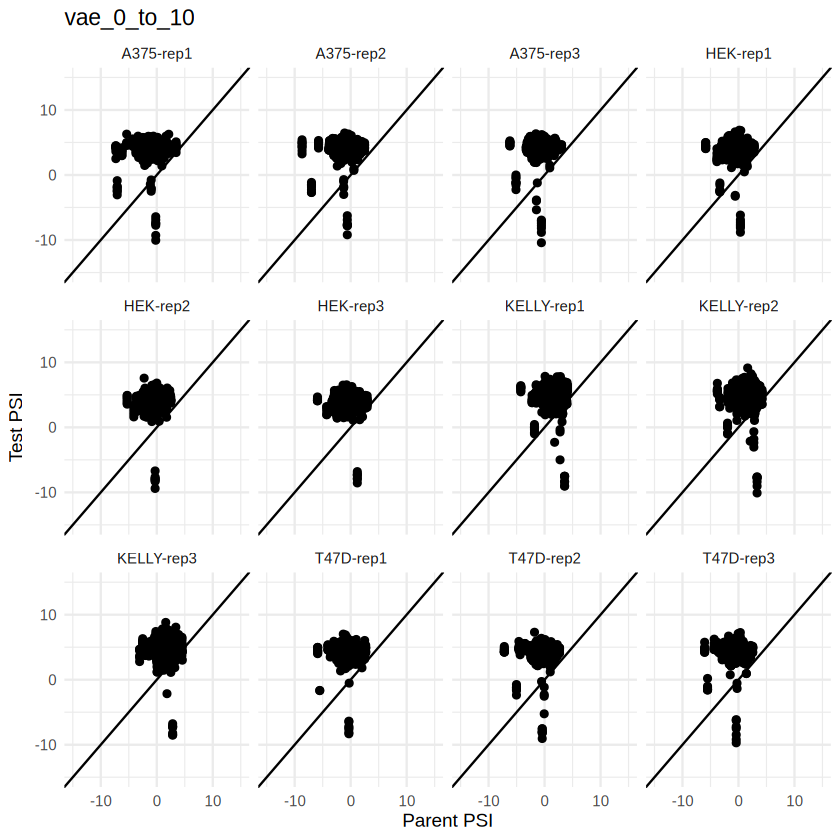

Warning message:
“Removed 4066 rows containing missing values or values outside the scale range
(`geom_point()`).”


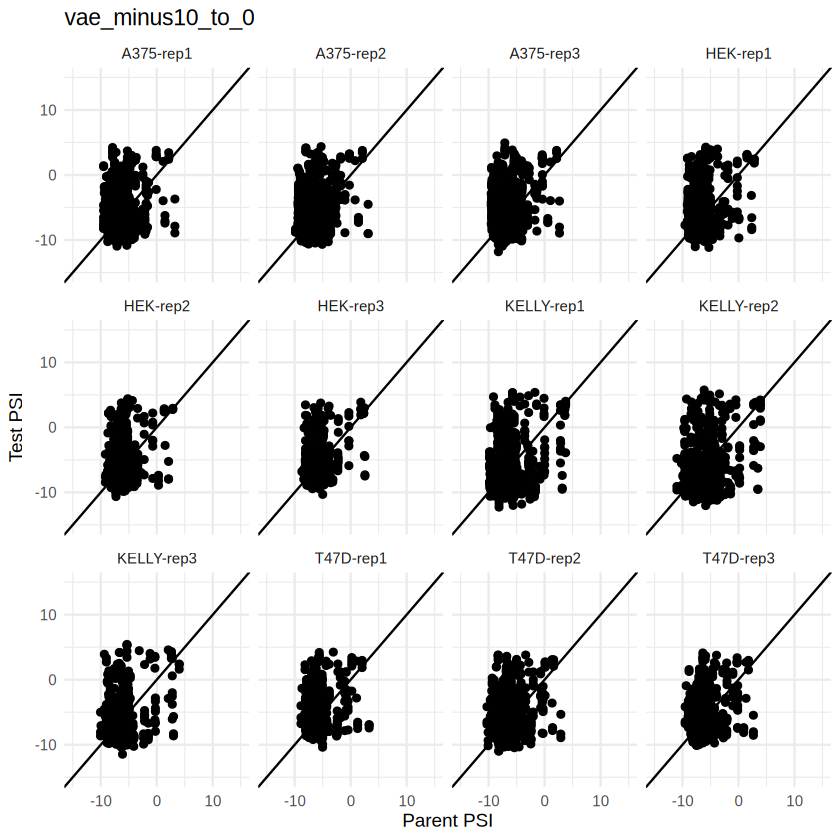

Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”


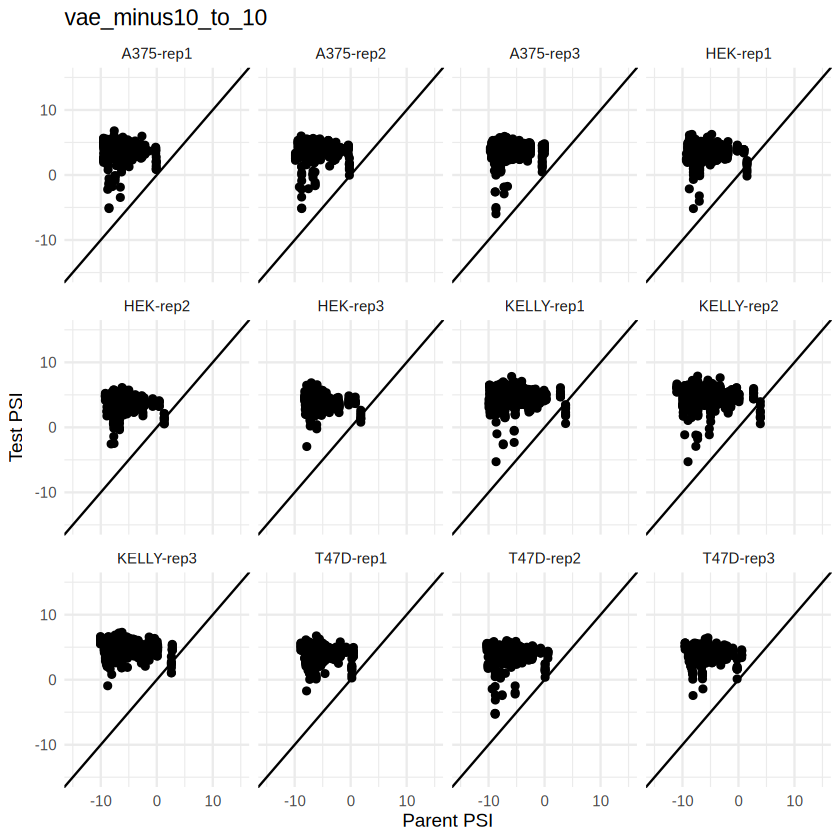

Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”


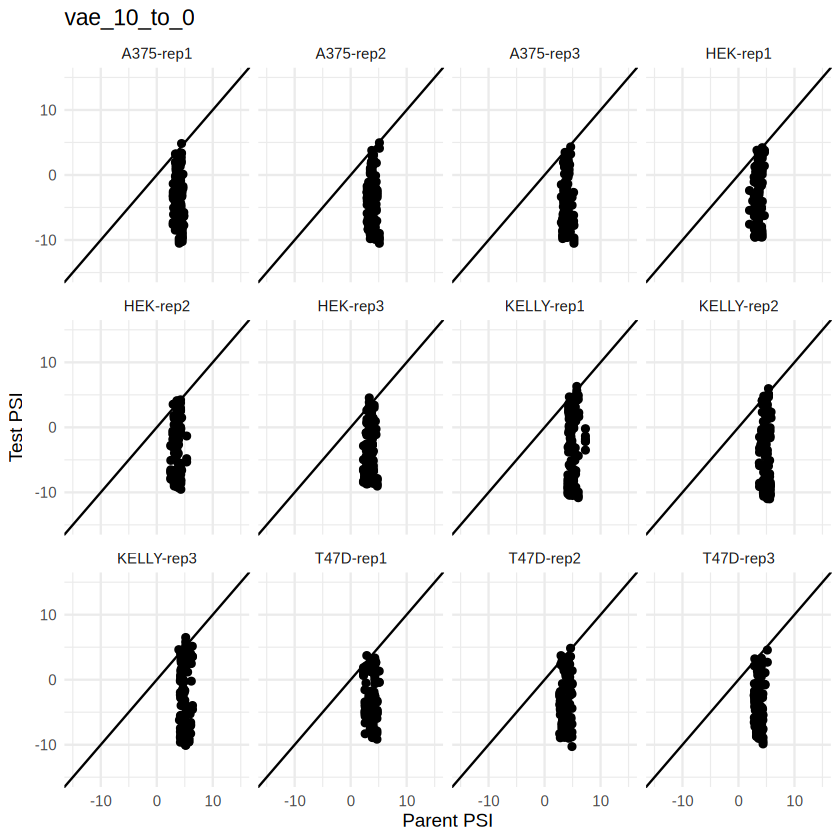

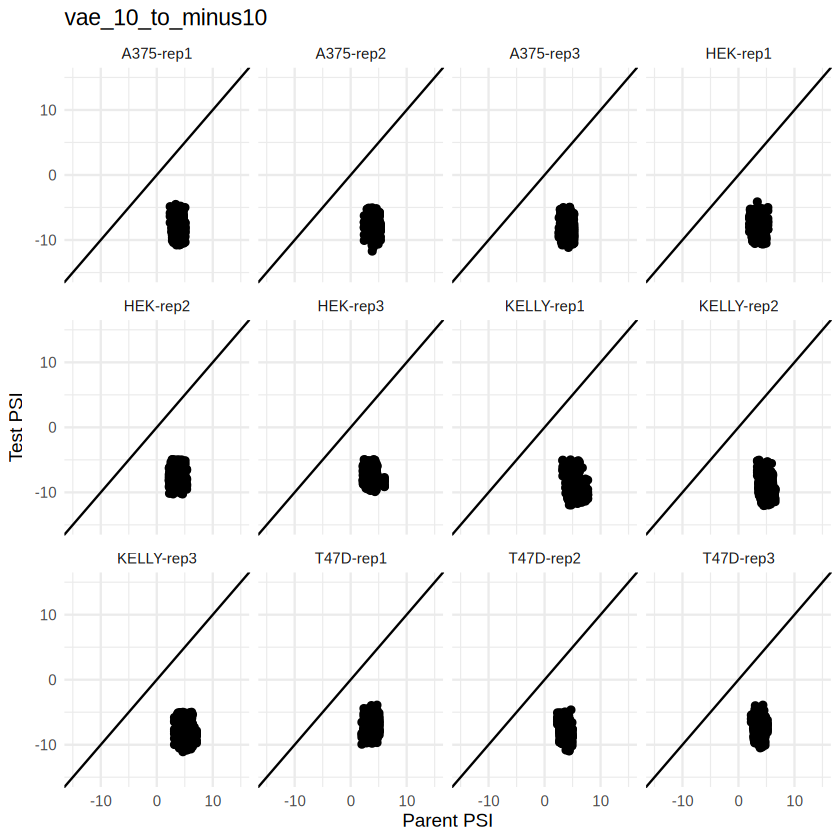

In [13]:
# Get the standard set. 
standard_set <- raw_df_to_psi %>% 
    filter(design == "R1design0") %>% 
    mutate(parent_PSI = PSI) %>%
    select(sample, condition, index_offset, parent_PSI)
    
test_set <- raw_df_to_psi %>% 
    filter(design != "R1design0") 

merged_back <- merge(test_set, standard_set, by = c("sample", "condition", "index_offset"), all.x = TRUE)

categories <- c("vae_0_to_minus10","vae_0_to_10", "vae_minus10_to_0", "vae_minus10_to_10", "vae_10_to_0", "vae_10_to_minus10")

output_filepath <- "/mnt/dawnccle2/melange/figures_outputs/R1_vae_validation"
# Create the output directory if it doesn't exist.
if (!dir.exists(output_filepath)) {
  dir.create(output_filepath, recursive = TRUE)
}

# Loop through each category and create/save plots
for(category_current in categories) {
    data_current <- merged_back %>%
        filter(grepl(category_current, design))
    
    p <- ggplot(data_current, aes(x = parent_PSI, y = PSI)) +
        geom_point() +
        geom_abline(slope = 1, intercept = 0) +
        theme_minimal() +
        labs(x = "Parent PSI", y = "Test PSI") +
        ggtitle(category_current) + 
        facet_wrap(~sample) + 
        xlim(-15, 15) +
        ylim(-15, 15)
    
    # Save plot
    ggsave(
        filename = file.path(output_filepath, 
                           paste0(category_current, "_plot.pdf")),
        plot = p,
        width = 12,
        height = 8
    )
    
    # Display plot in notebook
    print(p)
}
